---

# Aprendizaje de Maquina

### Carrera de Especializacion en Inteligencia Artificial

### Laboratorio de Sistemas Embebidos - Universidad Nacional de Buenos Aires

---

#### Objetivos de la materia:
El objetivo está centrado en disponer de las herramientas de machine learning como así también la pericia para poder evaluar de antemano los diferentes casos de aplicación de técnicas de machine learning.

#### Evaluación
La evaluación de los conocimientos impartidos durante las clases será a modo de entrega de trabajo práctico final. La entrega de trabajo final de la cursada comprende de una investigación, desarrollo y resultados finales basados en un set de datos a elección por el grupo (máximo 6 personas).

#### Criterios de aprobación
Los criterios de aprobación son los siguientes:

- Obligación de trabajar en grupo mínimo de 2 y máximo de 6. Excepciones se pueden hacer mediante un correcto justificativo.
- Cada TP debe citar la fuente de información de evaluación, es decir, citar de donde se obtuvieron los datos.
- Puede ser entregado en cualquier formato, preferentemente en notebook de ipython (formato ipynb). También puede entregarse mediante un documento en Google Colab.
- Contendrá la propuesta de investigación en los datos, citando el porqué de la evaluación y que se pretende encontrar o descubrir con dicha investigación
- Deberá explicar el porqué de la elección del algoritmo empleado para la resolución del problema y cómo llegó a esa elección por sobre otras opciones
- Deberá expresar de manera clara el resultado de la investigación aportando las métricas necesarias para comprender cómo se desempeña el algoritmo elegido.
- El entregable debe venir con el código acompañado para su reproducibilidad.
- En su cierre debe dar una reflexión de su investigación y proponer nuevos caminos de resolución en el caso de que sea necesario.
- Como última fecha de entrega del trabajo, estará limitado a 3 días posteriores a la última clase.
- La entrega es por el aula virtual, ya sea el envío del contenido o el link a repositorio (de GitHub o GitLab) con el trabajo.

## Análisis de Rentabilidad Películas

El presente modelo intenta generalizar los resultados económicos de una película en el momento previo a su estreno utilizando datos como género, idioma original, costo inicial, país de producción y demás.

Para su realización se utilizó el dataset de kaggle [Full TMDB Movies Dataset 2024](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies).

### Integrantes

- Matías Guillermo Alfaro
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

### Setup inicial y Carga de Datos

En esta sección, configuramos el entorno de análisis, importamos las bibliotecas necesarias y realizamos una exploración inicial de los datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe
from pathlib import Path
import shutil

In [3]:
# Create data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Download dataset (latest version by default)
download_path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Copy to local data directory
csv_file = next(Path(download_path).glob("*.csv"))
local_path = data_dir / csv_file.name
shutil.copy2(csv_file, local_path)

print(f"Dataset copied to: {local_path}")

Using Colab cache for faster access to the 'tmdb-movies-dataset-2023-930k-movies' dataset.
Dataset copied to: data/TMDB_movie_dataset_v11.csv


Carga del dataset

In [4]:
# Cargamos el dataset desde el directorio local de datos
data_path = "data/TMDB_movie_dataset_v11.csv"
df = pd.read_csv(data_path)

### Descripción de los datos

Dimensiones

In [5]:
print(f"Dimensiones del dataset original: {df.shape}")

Dimensiones del dataset original: (1437799, 24)


Información de columnas y tipos de datos

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1437799 entries, 0 to 1437798
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1437799 non-null  int64  
 1   title                 1437780 non-null  object 
 2   vote_average          1437799 non-null  float64
 3   vote_count            1437799 non-null  int64  
 4   status                1437799 non-null  object 
 5   release_date          1113213 non-null  object 
 6   revenue               1437799 non-null  int64  
 7   runtime               1437799 non-null  int64  
 8   adult                 1437799 non-null  bool   
 9   backdrop_path         355470 non-null   object 
 10  budget                1437799 non-null  int64  
 11  homepage              147500 non-null   object 
 12  imdb_id               672130 non-null   object 
 13  original_language     1437799 non-null  object 
 14  original_title        1437780 non-

### Análisis Exploratorio de Datos (EDA)

In [7]:
# exclude columns w/o valuable data (e.g. backdrop_path, imdb_id,..)
columns = ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'keywords']
df[columns].head()

,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,keywords
0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"new york city, superhero, shield, based on com..."


In [8]:
df[columns].describe()

,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.437799e+06,1.437799e+06,1.437799e+06,1.437799e+06,1.437799e+06,1.437799e+06
mean,1.537788e+00,1.492429e+01,6.171243e+05,4.372787e+01,2.339226e+05,9.985601e-01
std,2.847467e+00,2.832989e+02,1.965567e+07,6.057922e+01,5.125714e+06,6.762754e+00
min,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.140000e-02
50%,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,6.000000e-01
75%,0.000000e+00,0.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,6.880000e-01
max,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


#### Variables numéricas

<em>Nota: hay columnas con muchos valores en 0</em>

IMDB usa el 0 para representar "unknown", no el valor 0. Por eso usamos alternativamente las siguientes medidas para obtener resultados útiles:

In [9]:
# columnas numéricas
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('id')
print("Columnas numéricas:")
print(numerical_columns)

Columnas numéricas:
Index(['vote_average', 'vote_count', 'revenue', 'runtime', 'budget',
       'popularity'],
      dtype='object')


In [10]:
# esta función extrae max, min, mean, mode y median de cada columna numérica
# tanto para el dataset completo como para cada columna filtrando valores 0 o "unknown" (val > 0)
def extract_numerical_stats(df, columns):
    summary_data = []
    rounded_df = df[columns].round(2)  # Redondear a 2 decimales
    for column in columns:
        # unfiltered statistics
        max_value = rounded_df[column].max()
        min_value = rounded_df[column].min()
        mean_value = rounded_df[column].mean()
        mode_value = rounded_df[column].mode()[0] if not rounded_df[column].mode().empty else None
        median_value = rounded_df[column].median()
        unique_values = rounded_df[column].nunique()

        # filtered statistics (val > 0)
        filtered_df = rounded_df[rounded_df[column] > 0]
        filtered_min = filtered_df[column].min()
        filtered_mean = filtered_df[column].mean()
        filtered_mode = filtered_df[column].mode()[0] if not filtered_df[column].mode().empty else None
        filtered_median = filtered_df[column].median()
        filtered_unique_values = filtered_df[column].nunique()
        summary_data.append({
            'Column': column,
            'Max': max_value,
            'Min': min_value,
            'Filtered Min': filtered_min,
            'Mean': mean_value,
            'Filtered Mean': filtered_mean,
            'Mode': mode_value,
            'Filtered Mode': filtered_mode,
            'Median': median_value,
            'Filtered Median': filtered_median,
            'Unique Values': unique_values,
            'Filtered Unique Values': filtered_unique_values
        })
    return pd.DataFrame(summary_data)

numerical_stats_df = extract_numerical_stats(df, numerical_columns)
float_cols = numerical_stats_df.select_dtypes('float').columns
display(numerical_stats_df.style.format('{:.2f}', subset=float_cols))

,Column,Max,Min,Filtered Min,Mean,Filtered Mean,Mode,Filtered Mode,Median,Filtered Median,Unique Values,Filtered Unique Values
0,vote_average,10.00,0.00,0.50,1.54,6.16,0.00,6.00,0.00,6.00,776,775
1,vote_count,34495.00,0.00,1.00,14.92,59.74,0.00,1.00,0.00,2.00,3598,3597
2,revenue,4999999999.00,-12.00,1.00,617124.35,36155852.32,0.00,1.00,0.00,769119.00,14658,14656
3,runtime,14400.00,-28.00,1.00,43.73,63.49,0.00,90.00,15.00,61.00,822,820
4,budget,999999999.00,0.00,1.00,233922.59,4050943.86,0.00,100.00,0.00,3000.00,6637,6636
5,popularity,2994.36,0.00,0.01,1.00,1.21,0.60,0.60,0.60,0.60,4746,4745


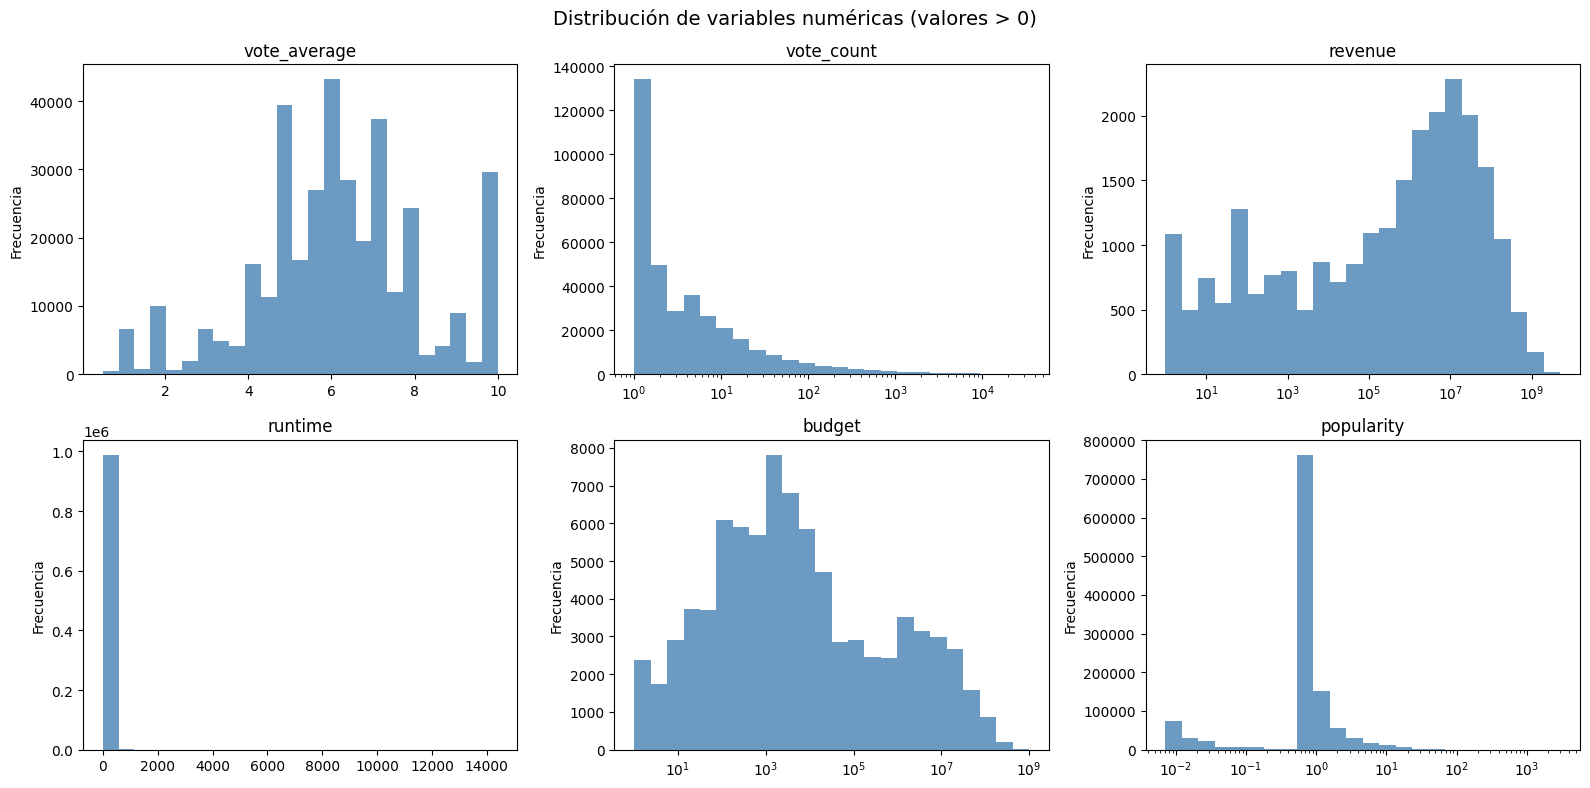

In [11]:
log_scale_cols = {'revenue', 'budget', 'vote_count', 'popularity'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    data = df[col][df[col] > 0]
    if col in log_scale_cols:
        bins = np.geomspace(data.min(), data.max(), 25)
        axes[i].set_xscale('log')
    else:
        bins = 25
    axes[i].hist(data, bins=bins, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (valores > 0)', fontsize=14)
plt.tight_layout()
plt.show()

#### Variables categóricas

In [12]:
categorical_columns = [
    "original_language",
    "genres",
    "production_countries",
    "production_companies",
]

df[categorical_columns].head()

,original_language,genres,production_countries,production_companies
0,en,"Action, Science Fiction, Adventure","United Kingdom, United States of America","Legendary Pictures, Syncopy, Warner Bros. Pict..."
1,en,"Adventure, Drama, Science Fiction","United Kingdom, United States of America","Legendary Pictures, Syncopy, Lynda Obst Produc..."
2,en,"Drama, Action, Crime, Thriller","United Kingdom, United States of America","DC Comics, Legendary Pictures, Syncopy, Isobel..."
3,en,"Action, Adventure, Fantasy, Science Fiction","United States of America, United Kingdom","Dune Entertainment, Lightstorm Entertainment, ..."
4,en,"Science Fiction, Action, Adventure",United States of America,Marvel Studios


Top 10 por variable:

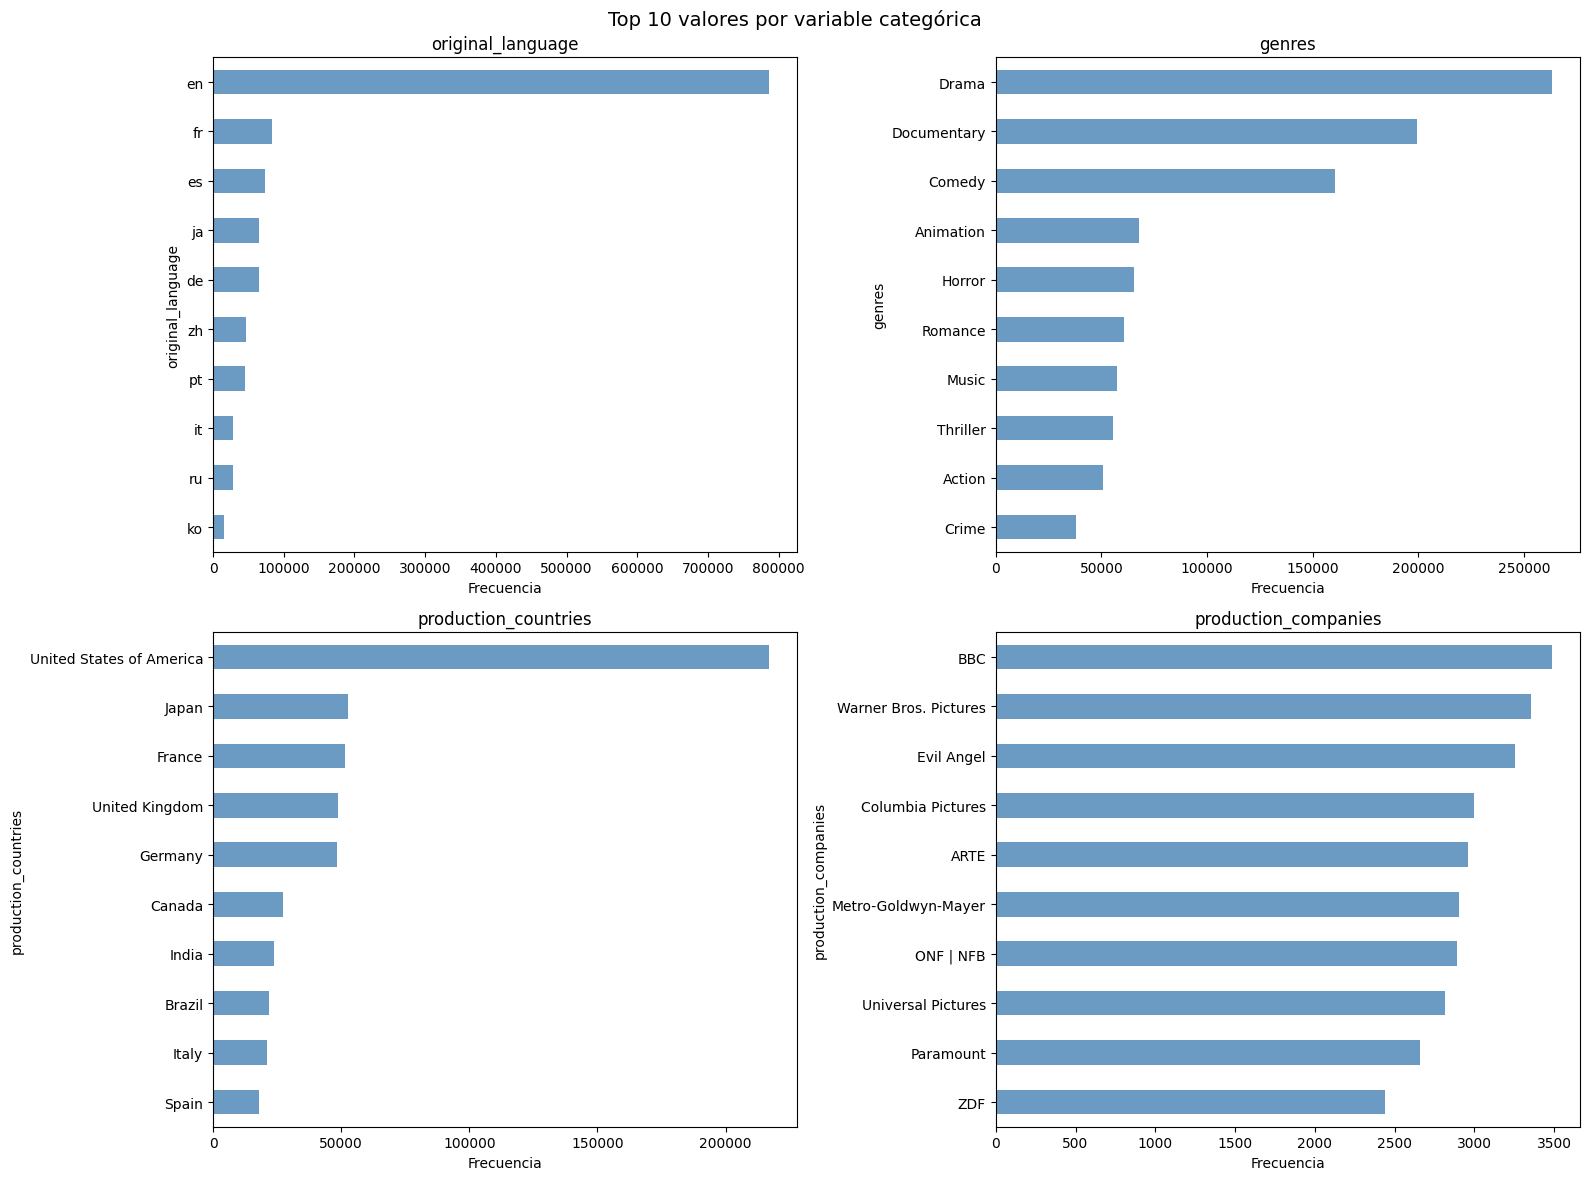

In [13]:
# Parse multi-value columns from comma-separated strings to lists
for col in ['genres', 'production_countries', 'production_companies', 'keywords']:
    df[col] = df[col].fillna('').apply(lambda x: [v.strip() for v in x.split(',') if v.strip()])

# Top-10 value counts per categorical column
cat_counts = {
    'original_language':    df['original_language'].value_counts(),
    'genres':               df.explode('genres')['genres'].value_counts(),
    'production_countries': df.explode('production_countries')['production_countries'].value_counts(),
    'production_companies': df.explode('production_companies')['production_companies'].value_counts(),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, counts) in enumerate(cat_counts.items()):
    counts.head(10).plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Frecuencia')

plt.suptitle('Top 10 valores por variable categórica', fontsize=14)
plt.tight_layout()
plt.show()

### Limpieza de datos

Eliminamos duplicados:

In [14]:
# eliminamos duplicados
df = df.drop_duplicates(subset='id')

Eliminamos películas para adultos:

In [15]:
df = df[df['adult'] == False]

Eliminamos entradas con runtime =< 0

In [16]:
# eliminamos entradas con valores no positivos en runtime
df = df[df['runtime'] > 0]

Eliminamos entradas con `revenue` y/o `budget` 0 en función de la variable target:

In [17]:
df_model = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

### Creación de la variable target: `profitable`

Generamos una nueva variable `profitable`, que es la que vamos a intentar predecir.

> `profitable = 1` si `revenue > budget`, en caso contrario `0`.

Este subconjunto, `df_model`, es el que usaremos para entrenamiento y evaluación.

In [18]:
df_model['profitable'] = (df_model['revenue'] > df_model['budget']).astype(int)

n_total = len(df_model)
n_prof  = df_model['profitable'].sum()
n_not   = n_total - n_prof

print(f"Películas con budget y revenue conocidos: {n_total:,}")
print(f"  Rentables:    {n_prof:,}  ({n_prof/n_total:.1%})")
print(f"  No rentables: {n_not:,}  ({n_not/n_total:.1%})")

Películas con budget y revenue conocidos: 14,528
  Rentables:    8,771  (60.4%)
  No rentables: 5,757  (39.6%)


#### Balance de clases

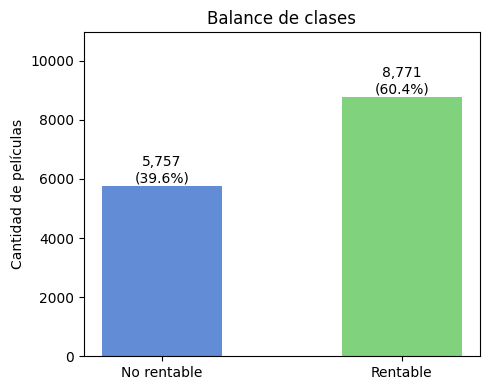

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ['No rentable', 'Rentable']
counts = [n_not, n_prof]
colors = ['#4878cf', '#6acc65']
bars = ax.bar(labels, counts, color=colors, edgecolor='none', alpha=0.85, width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{count:,}\n({count/n_total:.1%})', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Cantidad de películas')
ax.set_title('Balance de clases')
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.show()

### EDA con variable target

#### Variables numéricas según rentabilidad

Usamos violin plots para visualizar la distribución de cada variable numérica entre películas rentables y no rentables.

Las columnas con alta varianza (`revenue`, `budget`, `vote_count`, `popularity`) se muestran en escala logarítmica.

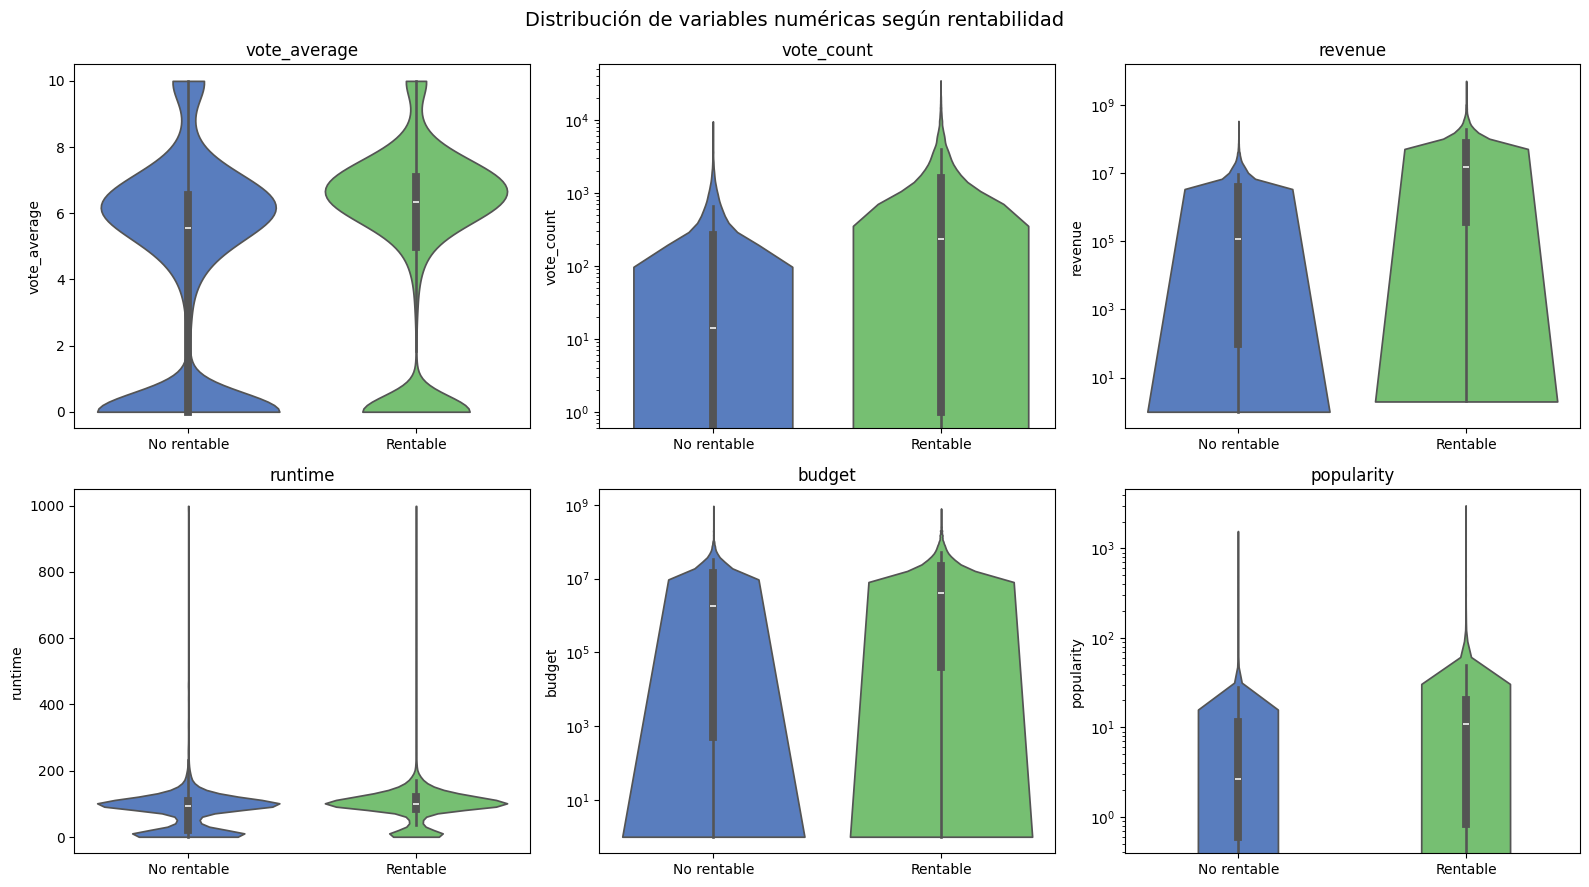

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.violinplot(
        data=df_model, x='profitable', y=col, ax=axes[i],
        hue='profitable', palette=['#4878cf', '#6acc65'],
        inner='box', cut=0, legend=False
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No rentable', 'Rentable'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    if col in log_scale_cols:
        axes[i].set_yscale('log')

plt.suptitle('Distribución de variables numéricas según rentabilidad', fontsize=14)
plt.tight_layout()
plt.show()

#### Matriz de correlación

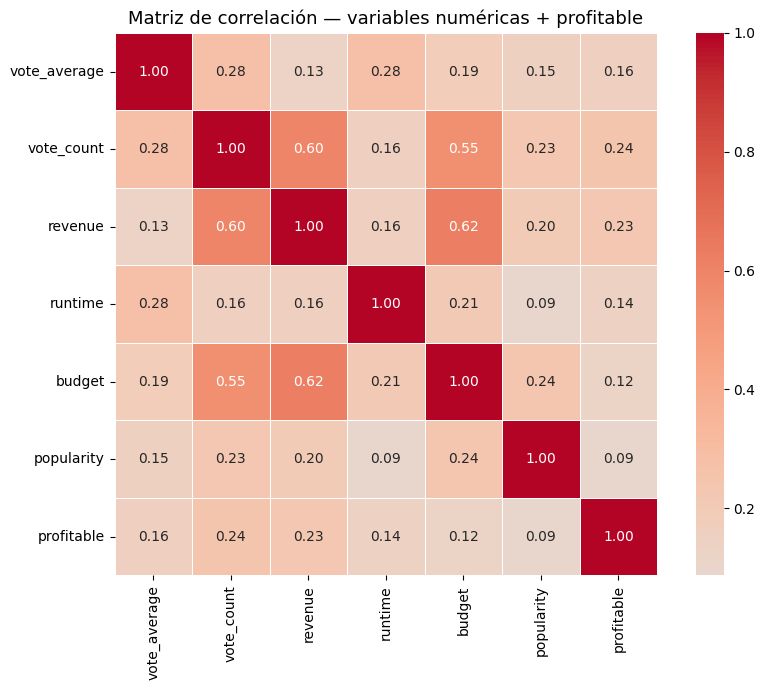

In [21]:
corr_cols = list(numerical_columns) + ['profitable']
corr = df_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Matriz de correlación — variables numéricas + profitable', fontsize=13)
plt.tight_layout()
plt.show()

#### Variables categóricas: tasa de rentabilidad

Tasa de rentabilidad por variable categórica:

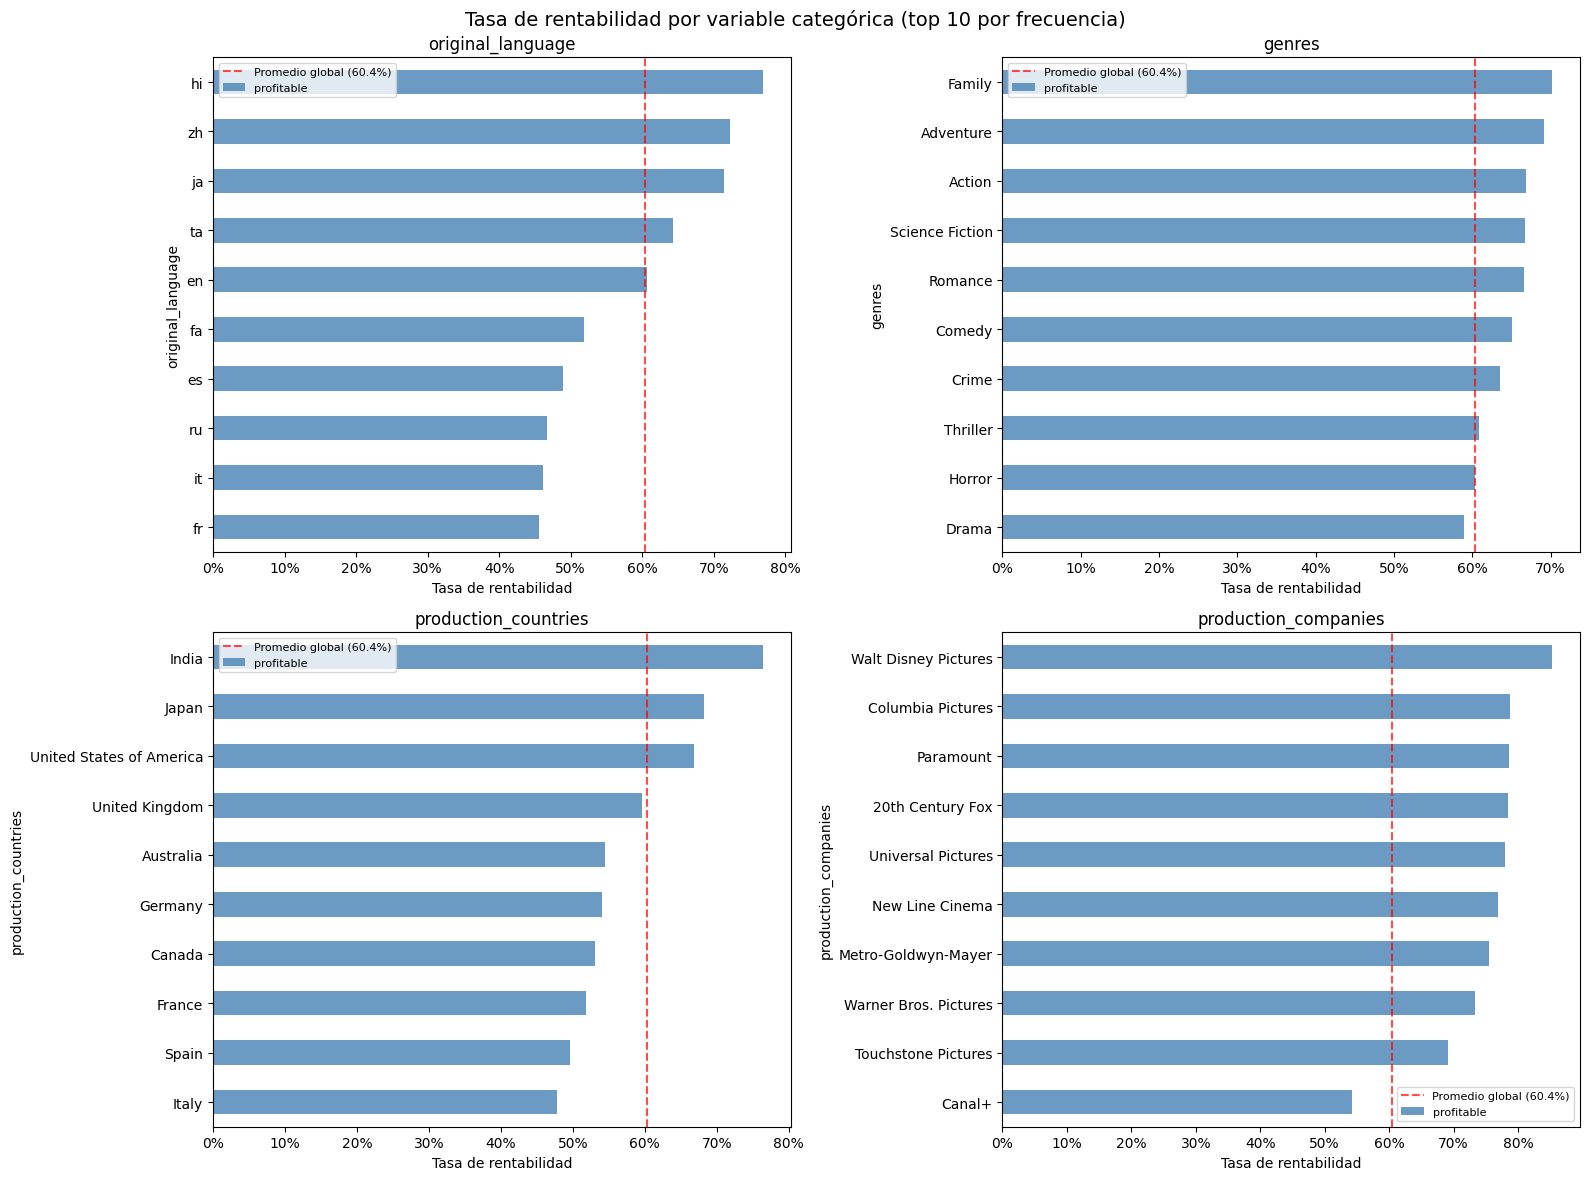

In [22]:
def profitability_rate_by_category(df, col, top_n=10):
    exploded = df.explode(col).dropna(subset=[col])
    exploded = exploded[exploded[col] != '']
    top_cats = exploded[col].value_counts().head(top_n).index
    return (
        exploded[exploded[col].isin(top_cats)]
        .groupby(col)['profitable']
        .mean()
        .sort_values(ascending=False)
    )

top_languages = df_model['original_language'].value_counts().head(10).index
lang_rate = (
    df_model[df_model['original_language'].isin(top_languages)]
    .groupby('original_language')['profitable']
    .mean()
    .sort_values(ascending=False)
)

rates = {
    'original_language':    lang_rate,
    'genres':               profitability_rate_by_category(df_model, 'genres'),
    'production_countries': profitability_rate_by_category(df_model, 'production_countries'),
    'production_companies': profitability_rate_by_category(df_model, 'production_companies'),
}

global_rate = df_model['profitable'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, rate) in enumerate(rates.items()):
    rate.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].axvline(global_rate, color='red', linestyle='--', alpha=0.7,
                    label=f'Promedio global ({global_rate:.1%})')
    axes[i].set_title(col)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Tasa de rentabilidad')
    axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[i].legend(fontsize=8)

plt.suptitle('Tasa de rentabilidad por variable categórica (top 10 por frecuencia)', fontsize=14)
plt.tight_layout()
plt.show()

### Ingeniería de features

Convertimos todas las variables al formato numérico que requieren los modelos.

| Variable | Transformación |
|---|---|
| `budget`, `runtime` | Se mantienen tal cual. El escalado se aplica **dentro del pipeline** de cada modelo que lo requiera (KNN, Regresión Logística, SVM). |
| `original_language` | Se conservan los `TOP_LANGUAGES` idiomas más frecuentes; el resto se agrupa como `"other"`. Luego one-hot encoding. |
| `genres` | Multi-hot encoding sobre todos los géneros presentes en el dataset. |
| `production_countries` | Multi-hot encoding sobre los `TOP_COUNTRIES` países más frecuentes. |
| `production_companies` | Multi-hot encoding sobre las `TOP_COMPANIES` productoras más frecuentes. El top-N limita el ruido por alta cardinalidad. |
| `revenue` | **Excluida**. No está disponible antes del estreno y define la variable target. |

In [23]:
from sklearn.preprocessing import MultiLabelBinarizer

TOP_LANGUAGES = 10
TOP_COUNTRIES = 10
TOP_COMPANIES = 15
TOP_KEYWORDS = 20

df_feat = df_model[['budget', 'runtime', 'original_language',
                     'genres', 'production_countries', 'production_companies',
                     'profitable', 'keywords', 'release_date']].copy()

# 1. original_language: top-N + "other", luego one-hot
top_langs = df_feat['original_language'].value_counts().head(TOP_LANGUAGES).index
df_feat['original_language'] = df_feat['original_language'].where(
    df_feat['original_language'].isin(top_langs), other='other'
)
lang_dummies = pd.get_dummies(df_feat['original_language'], prefix='lang')

# 2. genres: multi-hot encoding
mlb_genres = MultiLabelBinarizer()
genres_enc = pd.DataFrame(
    mlb_genres.fit_transform(df_feat['genres']),
    columns=[f'genre_{g}' for g in mlb_genres.classes_],
    index=df_feat.index
)

# 3. production_countries: multi-hot encoding top-N
top_countries = (
    df_feat.explode('production_countries')['production_countries']
    .value_counts().head(TOP_COUNTRIES).index
)
df_feat['production_countries'] = df_feat['production_countries'].apply(
    lambda lst: [c for c in lst if c in top_countries]
)
mlb_countries = MultiLabelBinarizer(classes=list(top_countries))
countries_enc = pd.DataFrame(
    mlb_countries.fit_transform(df_feat['production_countries']),
    columns=[f'country_{c}' for c in mlb_countries.classes_],
    index=df_feat.index
)

# 4. production_companies: multi-hot encoding top-N
top_companies = (
    df_feat.explode('production_companies')['production_companies']
    .value_counts().head(TOP_COMPANIES).index
)
df_feat['production_companies'] = df_feat['production_companies'].apply(
    lambda lst: [c for c in lst if c in top_companies]
)
mlb_companies = MultiLabelBinarizer(classes=list(top_companies))
companies_enc = pd.DataFrame(
    mlb_companies.fit_transform(df_feat['production_companies']),
    columns=[f'company_{c}' for c in mlb_companies.classes_],
    index=df_feat.index
)

# 5. keywords: multi-hot encoding top-N
top_keywords = (
    df_feat.explode('keywords')['keywords']
    .value_counts().head(TOP_KEYWORDS).index
)
df_feat['keywords'] = df_feat['keywords'].apply(
    lambda lst: [c for c in lst if c in top_keywords]
)
mlb_keywords = MultiLabelBinarizer(classes=list(top_keywords))
keywords_enc = pd.DataFrame(
    mlb_keywords.fit_transform(df_feat['keywords']),
    columns=[f'kw_{c}' for c in mlb_keywords.classes_],
    index=df_feat.index
)

# 6. release_month: one-hot encoding
df_feat['release_month'] = pd.to_datetime(df_feat['release_date']).dt.month.astype('Int64')
month_dummies = pd.get_dummies(df_feat['release_month'], prefix='month', dtype=int)

# 7. Ensamblar X e y
X = pd.concat([
    df_feat[['budget', 'runtime']],
    lang_dummies,
    genres_enc,
    countries_enc,
    companies_enc,
    keywords_enc,
    month_dummies,
], axis=1)
y = df_feat['profitable']

In [24]:
feature_groups = {
    'Numéricas':            [c for c in X.columns if c in ('budget', 'runtime')],
    'Idioma':               [c for c in X.columns if c.startswith('lang_')],
    'Géneros':              [c for c in X.columns if c.startswith('genre_')],
    'Países de producción': [c for c in X.columns if c.startswith('country_')],
    'Productoras':          [c for c in X.columns if c.startswith('company_')],
}
for group, cols in feature_groups.items():
    print(f"  {group}: {len(cols)} feature{'s' if len(cols) != 1 else ''}")
print(f"\nTotal: {X.shape[1]} features | {X.shape[0]:,} muestras")
X.head()

  Numéricas: 2 features
  Idioma: 11 features
  Géneros: 19 features
  Países de producción: 10 features
  Productoras: 15 features

Total: 89 features | 14,528 muestras


,budget,runtime,lang_en,lang_es,lang_fa,lang_fr,lang_hi,lang_it,lang_ja,lang_other,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,160000000,148,True,False,False,False,False,False,False,False,...,0,0,0,0,1,0,0,0,0,0
1,165000000,169,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,1,0
2,185000000,152,True,False,False,False,False,False,False,False,...,0,0,0,0,1,0,0,0,0,0
3,237000000,162,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,1
4,220000000,143,True,False,False,False,False,False,False,False,...,0,1,0,0,0,0,0,0,0,0


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14528 entries, 0 to 1436491
Data columns (total 89 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   budget                            14528 non-null  int64
 1   runtime                           14528 non-null  int64
 2   lang_en                           14528 non-null  bool 
 3   lang_es                           14528 non-null  bool 
 4   lang_fa                           14528 non-null  bool 
 5   lang_fr                           14528 non-null  bool 
 6   lang_hi                           14528 non-null  bool 
 7   lang_it                           14528 non-null  bool 
 8   lang_ja                           14528 non-null  bool 
 9   lang_other                        14528 non-null  bool 
 10  lang_ru                           14528 non-null  bool 
 11  lang_ta                           14528 non-null  bool 
 12  lang_zh                           1

### División train / test

Separamos el dataset en un conjunto de entrenamiento (80%) y uno de evaluación (20%). Usamos `stratify=y` para garantizar que la proporción de clases sea la misma en ambos conjuntos, dado el desbalance 60/40.

In [26]:
from sklearn.model_selection import train_test_split

assert X.isna().sum().sum() == 0, "X contiene valores nulos"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} muestras  ({y_train.mean():.1%} rentables)")
print(f"Test:  {X_test.shape[0]:,} muestras  ({y_test.mean():.1%} rentables)")

Train: 11,622 muestras  (60.4% rentables)
Test:  2,906 muestras  (60.4% rentables)


### Entrenamiento y Evaluación de Modelos

Implementamos algunos modelos y evaluamos su rendimiento

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from lightgbm import LGBMClassifier

In [28]:
def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name=""):
    """
    Entrena y evalúa un modelo
    """
    model.fit(X_train, y_train)

    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Métricas
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }

    # Resultados
    print(f"\nResultados para {model_name}:")
    print("-----------------------------------")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    # Matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    return metrics

### Justificación de los Modelos Seleccionados

Para predecir la rentabilidad, se implementó un enfoque comparativo mediante diversos algoritmos de aprendizaje supervisado, permitiendo contrastar distintas estrategias de modelado:

**Regresión Logística**: Se estableció como baseline o modelo de referencia. Permite determinar la complejidad del problema y proporcionar una métrica de referencia simple frente a modelos más complejos.

**Random Forest**: Fue seleccionado por su capacidad para modelar relaciones no lineales y capturar interacciones complejas entre variables (como la relación entre género, presupuesto y fecha de estreno) sin  requerir un preprocesamiento estricta de los datos.

**SVM (Support Vector Machine)**: Se incluyó para evaluar su capacidad de encontrar fronteras de decisión óptimas en espacios de alta dimensionalidad.

**LightGBM**: Fue el modelo con mejor desempeño. Su arquitectura optimizada para el procesamiento de datasets tabulares permitió obtener las métricas más sólidas y una mayor eficiencia en el ajuste de hiperparámetros.


Resultados para Regresión Logística:
-----------------------------------
accuracy: 0.6036
precision: 0.6036
recall: 1.0000
f1: 0.7528
roc_auc: 0.6231


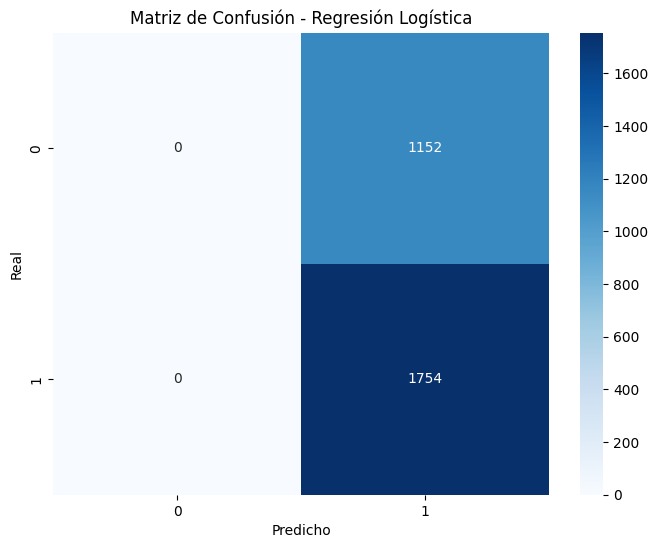


Resultados para Random Forest:
-----------------------------------
accuracy: 0.6717
precision: 0.6994
recall: 0.7999
f1: 0.7463
roc_auc: 0.7090


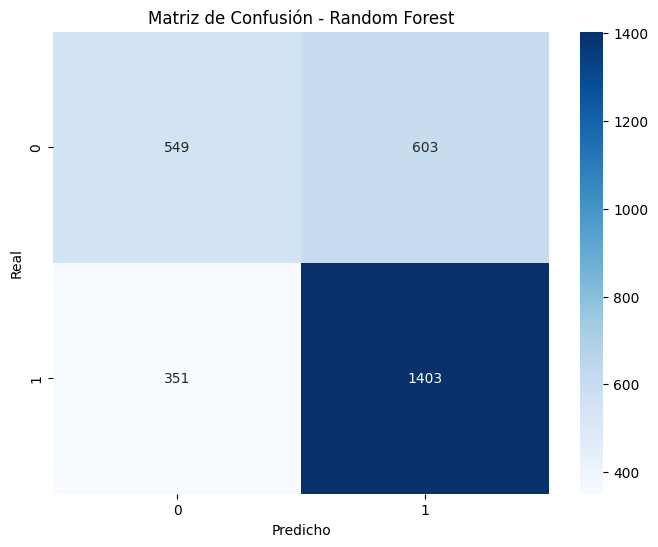


Resultados para SVM:
-----------------------------------
accuracy: 0.6036
precision: 0.6036
recall: 1.0000
f1: 0.7528
roc_auc: 0.5322


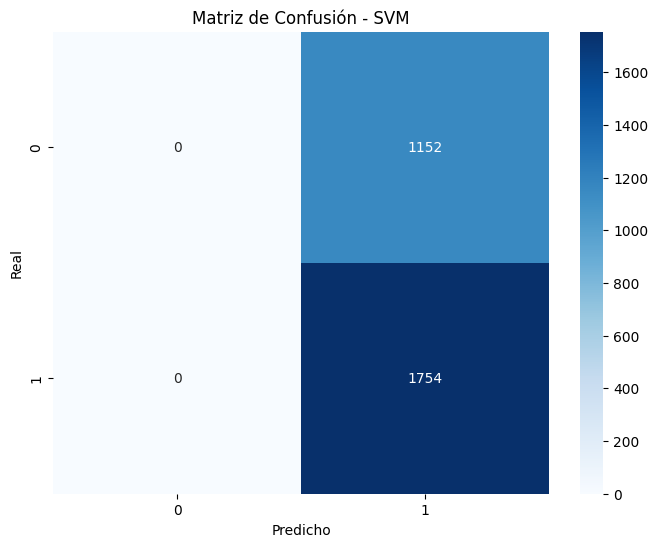

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7017, number of negative: 4605
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 11622, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.603769 -> initscore=0.421193
[LightGBM] [Info] Start training from score 0.421193

Resultados para LightGBM:
-----------------------------------
accuracy: 0.6666
precision: 0.6967
recall: 0.7925
f1: 0.7415
roc_auc: 0.7161


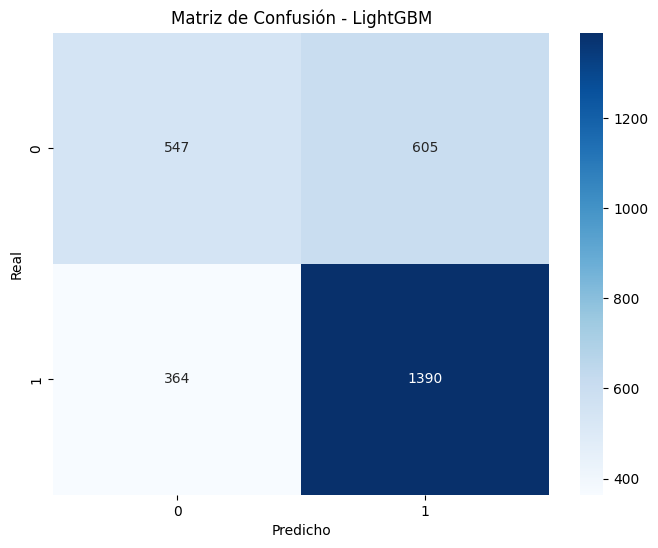

In [29]:
# Definición de modelos
models = {
    'Regresión Logística': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

# Entrenamiento y evaluación de cada modelo
results = {}
for name, model in models.items():
    results[name] = train_evaluate_model(
        model, X_train, X_test,
        y_train, y_test, name
    )

In [30]:
# Crear tabla comparativa final
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='f1', ascending=False))

,accuracy,precision,recall,f1,roc_auc
Regresión Logística,0.603579,0.603579,1.000000,0.752790,0.623090
SVM,0.603579,0.603579,1.000000,0.752790,0.532201
Random Forest,0.671714,0.699402,0.799886,0.746277,0.708981
LightGBM,0.666552,0.696742,0.792474,0.741531,0.716063


### Baseline

Para comparar nuestros modelos usaremos 2 Baselines heuristicos dados por los modelos LLM de las companias lideres en este momento, OpenIA y Anthropic. El reto es mejorar los resultados obtentidos por las funciones Heuristicas que pedimos armar a Chatgpt, usando GPT 5.5, y Claude, usando Sonnet 4.6.
A ambos modelos se les pidio armar una Heuristica que basado en el dataset de TMDB y usando las variables de una pelicula que se tengan antes del estreno si sera o no rentable, con la regla de conomiento del dominio de que la rentabilidad comienza a partir de un $revenue \geq 2,5 * budget$

A continuacion se detallan los criterios tenido en cuenta en cada funcion.

#### Heuristica GPT 5.5

Los pesos fueron definidos manualmente a partir de criterios observados en la industria cinematográfica. Por ejemplo:

- Los presupuestos(**budget**) extremadamente elevados son penalizados debido al mayor nivel de recaudación necesario para alcanzar la rentabilidad. Las producciones de bajo presupuesto son penalizadas al no tener un gran nivel de marketing y difusion. Lo optimo suele estar en presupuestos entre 20-100M usd.
- Las películas pertenecientes a franquicias o secuelas reciben una puntuación superior debido a la existencia de una audiencia previamente establecida. Para ello se usa el analisis de ciertas **keywords** que denotan estas pertenencias, tales como sequel, franchise o remake.
- Los estrenos en períodos de alta demanda (vacaciones de verano o fin de año) reciben una bonificación. Para ello se usa el mes extraido de la fecha de estreno(**release_date**).
- Determinadas productoras (**production_companies**) y géneros(**genres**) históricamente asociados a una mayor rentabilidad reciben una valoración positiva.
- Ciertos Paises(**production_countries**) e idiomas(**original_language**), son favorecidos por su ventaja comercial (USA, UKA, Canada, ingles) o sus mercados fuertes (Japon y Corea del Sur, con sus respectivos idiomas)
- Las peliculas con una duracion (**runtime**) entre 90 y 120 minutos, suele tener mayor exito frente a peliculas mas cortas o muy largas.

    |   pesos | feature score |
    |---------|---------------|
    |    0.15 | budget_score |
    |    0.15 | genre_score |
    |    0.10 | release_score |
    |    0.10 | runtime_score |
    |    0.20 | company_score |
    |    0.10 | country_score |
    |    0.05 | language_score |
    |    0.15 | keyword_score |

La puntuación final se normaliza en una escala de 0 a 100, donde valores mayores indican una mayor probabilidad de rentabilidad esperada. Se definió un umbral de 60 puntos sobre la para clasificar una película como potencialmente *rentable*. Este valor fue seleccionado de manera heurística, considerando que representa un desempeño superior al promedio en las variables analizadas.



In [ ]:
def gpt_budget_score(budget):
    if budget < 5_000_000:
        return 2
    elif budget < 20_000_000:
        return 8
    elif budget < 100_000_000:
        return 10
    elif budget < 200_000_000:
        return 6
    else:
        return 2


def gpt_runtime_score(runtime):
    if 90 <= runtime <= 120:
        return 10
    elif 120 < runtime <= 150:
        return 7
    elif 70 <= runtime < 90:
        return 6
    else:
        return 2


def gpt_language_score(row):
    scores = {
        "lang_en": 10,
        "lang_ja": 7,
        "lang_zh": 7,
        "lang_fr": 6,
        "lang_es": 5,
        "lang_it": 5,
        "lang_ru": 5,
        "lang_hi": 5,
        "lang_ta": 5,
        "lang_fa": 5,
        "lang_other": 4,
    }
    return max((value for key, value in scores.items() if row[key]),default=5)


def gpt_genre_score(row):
    scores = {
        "genre_Horror": 10,
        "genre_Thriller": 9,
        "genre_Mystery": 8,
        "genre_Comedy": 8,
        "genre_Crime": 7,
        "genre_Romance": 7,
        "genre_Drama": 6,
        "genre_Animation": 6,
        "genre_Action": 5,
        "genre_Science Fiction": 4,
        "genre_Fantasy": 3,
        "genre_Adventure": 3,
        "genre_War": 2,
        "genre_History": 2,
        "genre_Documentary": 2,
        "genre_Western": 2,
        "genre_Music": 4,
        "genre_Family": 6,
        "genre_TV Movie": 3
    }
    active = [value for key, value in scores.items()if row[key] == 1]
    return max(active, default=5)


def gpt_country_score(row):
    scores = {
        "country_United States of America": 10,
        "country_United Kingdom": 8,
        "country_Canada": 8,
        "country_Japan": 8,
        "country_France": 6,
        "country_Germany": 6,
        "country_Australia": 6,
        "country_Italy": 5,
        "country_Spain": 5,
        "country_India": 5,
    }
    active = [value for key, value in scores.items()if row[key] == 1]
    return max(active, default=4)


def gpt_company_score(row):
    scores = {
        "company_Walt Disney Pictures": 10,
        "company_Warner Bros. Pictures": 10,
        "company_Universal Pictures": 10,
        "company_Paramount": 9,
        "company_20th Century Fox": 9,
        "company_Columbia Pictures": 9,
        "company_Lionsgate": 8,
        "company_New Line Cinema": 8,
        "company_Metro-Goldwyn-Mayer": 7,
        "company_Miramax": 7,
        "company_Summit Entertainment": 7,
        "company_StudioCanal": 6,
        "company_United Artists": 6,
        "company_Touchstone Pictures": 6,
        "company_Canal+": 5,
    }
    active = [value for key, value in scores.items()if row[key] == 1]

    return max(active, default=5)


def gpt_keyword_score(row):
    positive = {
        "kw_sequel": 4,
        "kw_based on comic": 5,
        "kw_remake": 2,
        "kw_based on novel or book": 3,
        "kw_based on true story": 2,
        "kw_duringcreditsstinger": 3,
        "kw_aftercreditsstinger": 3,
    }

    negative = {
        "kw_biography": -1,
        "kw_woman director": -1,
    }

    score = 5
    score += sum(value for key, value in positive.items()if row[key] == 1)
    score += sum(value for key, value in negative.items()if row[key] == 1)

    return min(max(score, 0), 10)


def gpt_release_score(row):
    blockbuster_months = {
        "month_5",
        "month_6",
        "month_7",
        "month_11",
        "month_12",
    }

    good_months = {
        "month_3",
        "month_4",
    }

    if any(row[m] == 1 for m in blockbuster_months):
        return 10

    if any(row[m] == 1 for m in good_months):
        return 7

    return 5


def gpt_is_profitable(row):
    score = (
        0.15 * gpt_budget_score(row["budget"])
        + 0.15 * gpt_genre_score(row)
        + 0.10 * gpt_release_score(row)
        + 0.10 * gpt_runtime_score(row["runtime"])
        + 0.20 * gpt_company_score(row)
        + 0.10 * gpt_country_score(row)
        + 0.05 * gpt_language_score(row)
        + 0.15 * gpt_keyword_score(row)
    )

    return score * 10 >= 60

In [ ]:
print(gpt_is_profitable(X.iloc[0]))
print(gpt_is_profitable(X.iloc[1]))

True
True


#### Heuristica Sonnet 4.6

Una película se considera rentable cuando su revenue (taquilla mundial bruta) es al menos 2.5 veces su budget de producción. Este multiplicador aproxima el punto de equilibrio real considerando que los cines retienen ~50% de la taquilla y que los costos de marketing y distribución (P&A) suelen equivaler al 50–75% del presupuesto de producción, ninguno reflejado en las cifras de TMDB.

- **Criterio 1 — Budget tier (0–2 pts)**. Se clasifica el presupuesto en cinco tramos: micro (<$1M), indie ($1M–$10M), mid ($10M–$80M), tentpole ($80M–$200M) y mega (>$200M). La zona media (mid) recibe el puntaje máximo porque históricamente es donde el ROI es más predecible: hay presupuesto suficiente para distribución y marketing, pero el umbral de recuperación no es tan exigente como en los mega-blockbusters.
- **Criterio 2 — Género / ROI proporcional (0–2.5 pts)**. Cada género tiene asignado un coeficiente de ROI proporcional histórico. Horror encabeza el ranking porque sus presupuestos bajos generan retornos desproporcionados; Drama y Documentary reciben coeficientes bajos porque raramente cruzan el umbral de 2.5x. Cuando una película tiene múltiples géneros, el score pondera el mejor género (70%) y el promedio de todos (30%).
- **Criterio 3 — Temporada de estreno (0–2 pts)**. Mayo–Julio y Diciembre reciben el puntaje máximo por ser las temporadas de mayor afluencia histórica. Noviembre se beneficia del arranque de las fiestas. Enero y Febrero son los meses de peor performance promedio y reciben puntaje mínimo. Octubre recibe un bono moderado por el fenómeno de Halloween.
- **Criterio 4 — Idioma original (0–1 pt)**. Las películas en inglés acceden a un mercado de distribución global sustancialmente mayor. Las películas en otros idiomas reciben un puntaje parcial (0.3) para no descartarlas por completo, dado que existen excepciones notables, pero son la minoría estadística.
- **Criterio 5 — Respaldo de estudio grande (0–2 pts)**. La presencia de un estudio major es un proxy de capacidad de distribución y marketing masivo: acceso a miles de salas simultáneas, campañas globales y negociación favorable con exhibidores. La presencia de dos o más estudios grandes suma el puntaje máximo por indicar co-financiación multi-territorial.
- **Criterio 6 — Runtime (0–0.5 pts)**. Las películas entre 80 y 140 minutos maximizan la cantidad de funciones diarias que un cine puede programar. Las muy cortas (<70 min) suelen percibirse como contenido de TV; las muy largas (>140 min) reducen el número de funciones y pueden desincentivar la asistencia repetida.

≥ 7 puntos → perfil de película que probablemente ganó dinero

4–6 → zona gris

< 4 → perfil de pérdida probable

In [ ]:
# Heusristica Sonnet 4.6 de Anthropic

GENRE_ROI_SCORE = {
    "Horror": 2.0, "Animation": 1.8, "Family": 1.6, "Adventure": 1.4,
    "Science Fiction": 1.3, "Action": 1.2, "Comedy": 1.1, "Thriller": 1.0,
    "Mystery": 1.0, "Fantasy": 0.9, "Crime": 0.8, "Romance": 0.8,
    "Drama": 0.7, "War": 0.6, "Western": 0.6, "History": 0.5,
    "Documentary": 0.5, "Music": 0.5, "TV Movie": 0.3,
}

SEASON_SCORE = {
    1: 0.3, 2: 0.4, 3: 0.7, 4: 0.7,  5: 1.0,
    6: 1.0, 7: 1.0, 8: 0.8, 9: 0.5, 10: 0.6,
    11: 0.9, 12: 1.0,
}

MAJOR_STUDIO_COLS = {
    "company_Warner Bros. Pictures", "company_Universal Pictures",
    "company_Paramount", "company_20th Century Fox", "company_Columbia Pictures",
    "company_Metro-Goldwyn-Mayer", "company_New Line Cinema",
    "company_Walt Disney Pictures", "company_Miramax", "company_Lionsgate",
    "company_United Artists", "company_StudioCanal", "company_Summit Entertainment",
}

GENRE_COLS = [
    "genre_Action", "genre_Adventure", "genre_Animation", "genre_Comedy",
    "genre_Crime", "genre_Documentary", "genre_Drama", "genre_Family",
    "genre_Fantasy", "genre_History", "genre_Horror", "genre_Music",
    "genre_Mystery", "genre_Romance", "genre_Science Fiction",
    "genre_TV Movie", "genre_Thriller", "genre_War", "genre_Western",
]

MONTH_COLS = [
    "month_1", "month_2", "month_3", "month_4", "month_5", "month_6",
    "month_7", "month_8", "month_9", "month_10", "month_11", "month_12",
]


def sonnet_score_budget(budget):
    if budget < 1_000_000:
        return 0.5
    elif budget < 10_000_000:
        return 1.0
    elif budget < 80_000_000:
        return 2.0
    elif budget < 200_000_000:
        return 1.5
    else:
        return 1.0


def sonnet_score_genre(row):
    active = [col.replace("genre_", "") for col in GENRE_COLS if row[col] == 1]
    if not active:
        return 0.5
    scores = [GENRE_ROI_SCORE.get(g, 0.7) for g in active]
    best = max(scores)
    avg = sum(scores) / len(scores)
    return round(min((best * 0.7 + avg * 0.3) * 1.25, 2.5), 2)


def sonnet_score_season(row):
    for col in MONTH_COLS:
        if row[col] == 1:
            month_number = int(col.replace("month_", ""))
            return round(SEASON_SCORE[month_number] * 2, 2)
    return 1.0


def sonnet_score_language(row):
    return 1.0 if row["lang_en"] else 0.3


def sonnet_score_studio(row):
    matches = sum(1 for col in MAJOR_STUDIO_COLS if row.get(col, 0) == 1)
    if matches >= 2:
        return 2.0
    elif matches == 1:
        return 1.3
    else:
        return 0.0


def sonnet_score_runtime(runtime):
    if 80 <= runtime <= 140:
        return 0.5
    elif runtime < 70:
        return 0.1
    else:
        return 0.2


def sonnet_is_profitable(row):
    total = (
        sonnet_score_budget(row["budget"])
        + sonnet_score_genre(row)
        + sonnet_score_season(row)
        + sonnet_score_language(row)
        + sonnet_score_studio(row)
        + sonnet_score_runtime(row["runtime"])
    )
    return total >= 7.0

In [ ]:
print(sonnet_is_profitable(X.iloc[0]))
print(sonnet_is_profitable(X.iloc[1]))

True
False


### Conclusión

El análisis realizado confirma que la rentabilidad de un filme depende de la interacción compleja entre múltiples factores. Los modelos entrenados, especialmente LightGBM, lograron detectar patrones en los datos que las reglas de negocio manuales no alcanzan a cubrir por sí solas. Esto demuestra que el aprendizaje automático aporta una precisión superior al momento de analizar comportamientos complejos en el mercado.

Principales conclusiones:

- Al comparar el rendimiento de los modelos con las heurísticas generadas por modelos de lenguaje (GPT y Claude), observamos que los algoritmos detectan matices y correlaciones que las reglas manuales pasan por alto. Esto valida el uso de Machine Learning como un complemento necesario para entender la dinámica comercial del cine.

- Los datos confirman que variables como el mes de estreno, las keywords de franquicias y el perfil de las productoras tienen un peso crítico en el éxito comercial. El modelo logró identificar que estos elementos actúan como indicadores tempranos que, combinados, explican mejor la rentabilidad que el análisis aislado de una sola variable.

- Se observa un desequilibrio en la distribución de la variable objetivo (aprox. 60% rentable / 40% no rentable). Este sesgo refleja la realidad de la industria, donde el éxito comercial es menos frecuente que el rendimiento estándar. Si bien los modelos han mostrado un desempeño robusto bajo esta configuración, para futuras iteraciones optimizaremos la detección de la clase minoritaria aplicando técnicas de re-muestreo.

- Dinámica de rentabilidad: El éxito no es un fenómeno lineal ni aislado, es el resultado de una combinación de factores donde el presupuesto y el género se sincronizan con las tendencias de mercado. Los modelos como Random Forest y LightGBM resultaron ser las herramientas más efectivas para descodificar esta estructura.

En resumen, este trabajo valida que las técnicas de aprendizaje automático son una herramienta muy potente para analizar el mercado cinematográfico. Al contrastar nuestras predicciones con los criterios tradicionales, confirmamos que los algoritmos aportan una visión técnica más refinada sobre los factores que realmente impulsan la rentabilidad en la industria.